# Simulación M/M/1/K para Tráfico de Paquetes en 5G


## Introducción
Las redes 5G deben gestionar grandes volúmenes de tráfico de datos manteniendo bajos niveles de latencia y pérdida de paquetes para garantizar una adecuada calidad de servicio (QoS). Para analizar el comportamiento de estos sistemas bajo diferentes condiciones de carga, es común utilizar modelos de teoría de colas que permiten representar la llegada y atención de solicitudes de manera probabilística.

En este trabajo se estudia el tráfico de paquetes en el canal de subida de una estación base 5G mediante un modelo M/M/1/K, donde las llegadas siguen un proceso de Poisson, los tiempos de servicio tienen distribución exponencial y la capacidad del sistema es finita. A través de simulación y análisis matemático se evalúan indicadores clave como la probabilidad de pérdida de paquetes, la utilización del servidor, la longitud promedio de la cola y el tiempo medio de espera.

Además, se analiza el efecto de aumentar la capacidad de procesamiento del sistema, comparando el comportamiento original con un escenario de mayor tasa de servicio. Los resultados permiten comprender el impacto de la capacidad de atención sobre la congestión y la calidad del servicio en redes 5G.


## Planteamiento del problema
Se considera una estación base 5G que recibe paquetes generados por los usuarios con una tasa de llegada de λ=180 paquetes/s. El canal de subida puede atender paquetes con una tasa de servicio de μ=200 paquetes/s y dispone de un búfer con capacidad para 5 paquetes en espera.

Cuando un paquete llega y el sistema se encuentra completamente ocupado, este es descartado. Utilizando una simulación de al menos 10^6 llegadas, se busca estimar la probabilidad de pérdida de paquetes, la utilización del servidor, la longitud media de la cola y el tiempo medio de espera, comparando posteriormente los resultados con las expresiones analíticas del modelo M/M/1/K. Finalmente, se evalúa el impacto de duplicar la tasa de servicio a μ=400 paquetes/s y su efecto sobre el desempeño y la QoS del sistema.

## Entendimiento del modelo M/M/1/K

El modelo M/M/1/K es un sistema de colas utilizado para representar procesos donde las solicitudes llegan de forma aleatoria, son atendidas por un único servidor y la capacidad total del sistema es limitada. La notación de Kendall se interpreta de la siguiente manera:

- **M**: llegadas según un proceso de Poisson (tiempos entre llegadas exponenciales).
- **M**: tiempos de servicio con distribución exponencial.
- **1**: un único servidor.
- **K**: capacidad máxima del sistema (servidor + cola).

En este tipo de modelo, cuando una solicitud llega y el sistema ya ha alcanzado su capacidad máxima, dicha solicitud no puede ingresar y es descartada. Por esta razón, el modelo permite analizar fenómenos como la congestión, la utilización de recursos y la pérdida de paquetes.

Este modelo resulta especialmente útil en redes de comunicaciones modernas, incluyendo redes 5G, donde los paquetes de datos llegan de manera aleatoria y deben ser procesados por recursos limitados como buffers, estaciones base o nodos de red.

### Principales métricas de desempeño

Entre los indicadores más importantes que pueden obtenerse mediante este modelo se encuentran:

- **Probabilidad de bloqueo ($P_{bloqueo}$):** probabilidad de que un paquete sea descartado porque el sistema se encuentra lleno.
- **Utilización del servidor ($\rho$):** fracción del tiempo durante la cual el servidor permanece ocupado.
- **Longitud media del sistema ($L$):** número promedio de paquetes presentes en el sistema.
- **Longitud media de la cola ($L_q$):** número promedio de paquetes esperando atención.
- **Tiempo medio en el sistema ($W$):** tiempo promedio que un paquete permanece dentro del sistema.
- **Tiempo medio de espera ($W_q$):** tiempo promedio que un paquete espera en cola antes de ser atendido.
- **Throughput ($X$):** tasa efectiva de paquetes procesados por el sistema.



### Parámetros del modelo

Para realizar los cálculos y la simulación del sistema M/M/1/K se utilizan los siguientes parámetros:

- **$\lambda$ (lambda):** tasa media de llegada de paquetes al sistema, medida en paquetes por segundo (paquetes/s). Representa la intensidad con la que los paquetes ingresan a la cola.
- **$\mu$ (mu):** tasa media de servicio del servidor, medida en paquetes por segundo (paquetes/s). Indica la capacidad de procesamiento del sistema.
- **$K$:** capacidad máxima del sistema, incluyendo tanto los paquetes en espera como el que se encuentra siendo atendido. Cuando se alcanza este límite, los nuevos paquetes son descartados.
- **$\rho$ (rho):** intensidad de tráfico o factor de utilización del servidor. Este parámetro permite evaluar el nivel de carga del sistema y se define como:

$$
\rho = \frac{\lambda}{\mu}
$$

La relación entre $\lambda$ y $\mu$ determina el comportamiento de la cola:

- Si $\rho < 1$, el servidor puede atender los paquetes más rápido de lo que llegan y el sistema tiende a ser estable.
- Si $\rho \approx 1$, el sistema opera cerca de su capacidad máxima y pueden producirse mayores tiempos de espera.
- Si $\rho > 1$, las llegadas superan la capacidad de servicio, aumentando la probabilidad de congestión y pérdida de paquetes.

### Probabilidad de bloqueo

Debido a que la capacidad del sistema es finita, existe una probabilidad de que un paquete sea rechazado cuando el sistema se encuentra lleno. Esta métrica se conoce como probabilidad de bloqueo y corresponde a la probabilidad de que el sistema se encuentre en el estado \(K\):

$$
P_{bloqueo}=P_K
$$

Una elevada probabilidad de bloqueo indica saturación del sistema y una degradación en la calidad del servicio, aspecto particularmente relevante en aplicaciones de baja latencia y alta confiabilidad en redes 5G.

## Establecimiento de Librerías y parámetros básicos
En este bloque se cargan las librerías necesarias para realizar los cálculos matemáticos, almacenar resultados en tablas y generar gráficos.
Además, se definen los parámetros principales del problema:

- λ = 180 paquetes/s (tasa de llegada).
- BUFFER = 5 paquetes en espera.
- 1,000,000 de llegadas simuladas.
- Se fija una semilla aleatoria para que los resultados sean reproducibles.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque

LAMBDA = 180
BUFFER = 5
N_ARRIVALS = 1_000_000
np.random.seed(123)


## Funciones analíticas y de simulación

*Función analítica M/M/1/K:* Esta función calcula los resultados teóricos del sistema M/M/1/K utilizando las fórmulas de teoría de colas. Permite recolectar los datos de: 

 - Factor de utilización (ρ).
 - Probabilidad de bloqueo.
 - Utilización del servidor.
 - Longitud promedio de cola.
 - Tiempo medio de espera.
 - Distribución de probabilidades de cada estado del sistema.

*Función de simulación:* La función realiza una simulación de eventos discretos para reproducir el comportamiento real del sistema. Se generan:

- Llegadas aleatorias de paquetes.
- Tiempos de servicio aleatorios.
- Eventos de aceptación o rechazo de paquetes.


In [24]:
def analytic_mm1k(lam, mu, K):
    N = K + 1
    rho = lam/mu
    p0 = (1-rho)/(1-rho**(N+1)) if abs(rho-1)>1e-12 else 1/(N+1)
    probs = [p0*(rho**n) for n in range(N+1)]
    p_block = probs[N]
    util = 1-p0
    L = sum(n*p for n,p in enumerate(probs))
    Lq = L - util
    lam_eff = lam*(1-p_block)
    Wq = Lq/lam_eff
    return {'rho':rho,'p_block':p_block,'util':util,'Lq':Lq,'Wq':Wq,'probs':probs}

def simulate_mm1k(lam, mu, K, n_arrivals=1000000):
    inter = np.random.exponential(1/lam, n_arrivals)
    arrivals = np.cumsum(inter)
    dep = deque()
    server_free = 0
    lost=0
    waits=[]
    queue_lengths=[]
    busy_arrivals=0
    for t in arrivals:
        while dep and dep[0] <= t:
            dep.popleft()
        in_system=len(dep)
        q=max(0,in_system-1)
        queue_lengths.append(q)
        if in_system>0:
            busy_arrivals += 1
        if in_system >= K+1:
            lost += 1
            continue
        st=np.random.exponential(1/mu)
        start=max(t,server_free)
        waits.append(start-t)
        finish=start+st
        dep.append(finish)
        server_free=finish
    served=n_arrivals-lost
    return {
      'p_block':lost/n_arrivals,
      'util':busy_arrivals/n_arrivals,
      'Lq':float(np.mean(queue_lengths)),
      'Wq':float(np.mean(waits)),
      'served':served,
      'lost':lost
    }


## Escenario Original teniendo μ=200

Para el caso original planteado en el problema:
- λ=180
- μ=200
- K=5 

## Gráfico 1: Comparación analítico vs simulado

In [32]:
a200 = analytic_mm1k(180,200,5)
s200 = simulate_mm1k(180,200,5,N_ARRIVALS)

df200 = pd.DataFrame({
 'Métrica':['P_bloqueo','Utilización','Lq','Wq'],
 'Analítico':[a200['p_block'],a200['util'],a200['Lq'],a200['Wq']],
 'Simulado':[s200['p_block'],s200['util'],s200['Lq'],s200['Wq']]
})
df200


,Métrica,Analítico,Simulado
0,P_bloqueo,0.101867,0.102115
1,Utilización,0.808320,0.809010
2,Lq,1.774087,1.779656
3,Wq,0.010974,0.010997


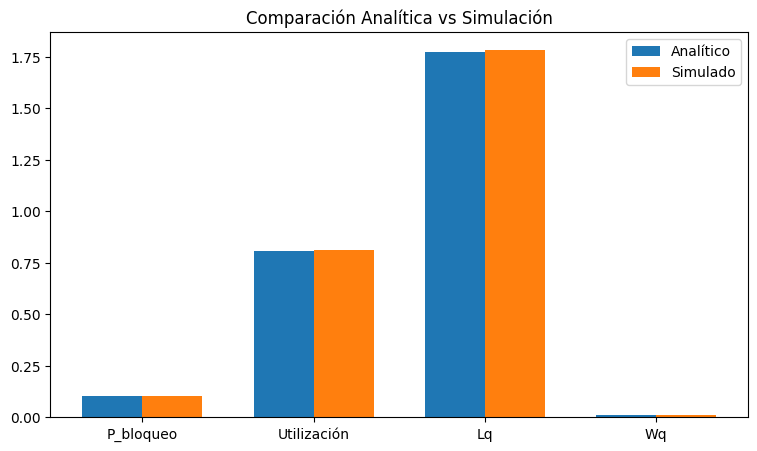

In [34]:
metrics=['P_bloqueo','Utilización','Lq','Wq']
x=np.arange(len(metrics))
w=0.35
plt.figure(figsize=(9,5))
plt.bar(x-w/2,df200['Analítico'],w,label='Analítico')
plt.bar(x+w/2,df200['Simulado'],w,label='Simulado')
plt.xticks(x,metrics)
plt.title('Comparación Analítica vs Simulación')
plt.legend()
plt.show()


## Gráfico 2: Probabilidades de estado y probabilidad de pérdida

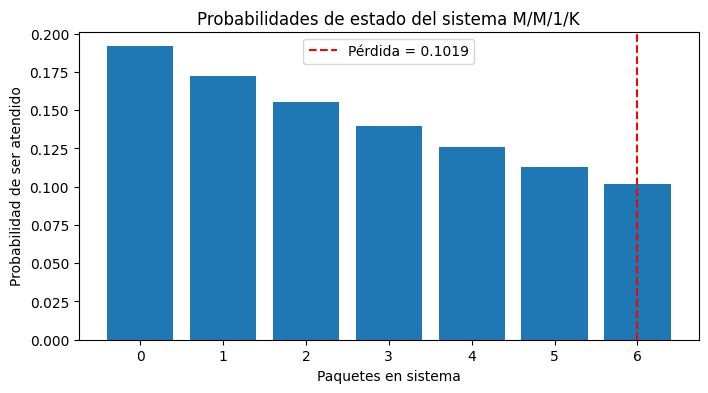

,Estado,Probabilidad,Probabilidad (%)
0,0,0.191680,19.167990
1,1,0.172512,17.251191
2,2,0.155261,15.526072
3,3,0.139735,13.973465
4,4,0.125761,12.576118
5,5,0.113185,11.318507
6,6,0.101867,10.186656


In [37]:
states = np.arange(len(a200['probs']))
plt.figure(figsize=(8,4))
plt.bar(states,a200['probs'])
plt.axvline(len(states)-1,color='red',linestyle='--',label=f'Pérdida = {a200["p_block"]:.4f}')
plt.title('Probabilidades de estado del sistema M/M/1/K')
plt.xlabel('Paquetes en sistema')
plt.ylabel('Probabilidad de ser atendido')
plt.legend()
plt.show()

df_estados = pd.DataFrame({    'Estado': states,    'Probabilidad': a200['probs'],    'Probabilidad (%)': [p * 100 for p in a200['probs']]})
df_estados

## Incremento del valor de μ a 400

A fin de poder estudiar el impacto de mejorar los recursos de la estación base se hará un incremnento de μ desde 200 a 400.


In [40]:
a400 = analytic_mm1k(180,400,5)
s400 = simulate_mm1k(180,400,5,N_ARRIVALS)

compare_mu = pd.DataFrame({
    'Métrica':['P_bloqueo','Utilización','Lq','Wq'],
    'μ=200':[s200['p_block'],s200['util'],s200['Lq'],s200['Wq']],
    'μ=400':[s400['p_block'],s400['util'],s400['Lq'],s400['Wq']]
})

# Porcentaje de cambio de disponibilidad
compare_mu['Cambio (%)'] = (
    (compare_mu['μ=400'] - compare_mu['μ=200'])
    / compare_mu['μ=200']
) * 100

compare_mu

,Métrica,μ=200,μ=400,Cambio (%)
0,P_bloqueo,0.102115,0.004714,-95.383636
1,Utilización,0.809010,0.447707,-44.659893
2,Lq,1.779656,0.345055,-80.611141
3,Wq,0.010997,0.001922,-82.525377


## Gráfico 3: Impacto de duplicar la capacidad de servicio

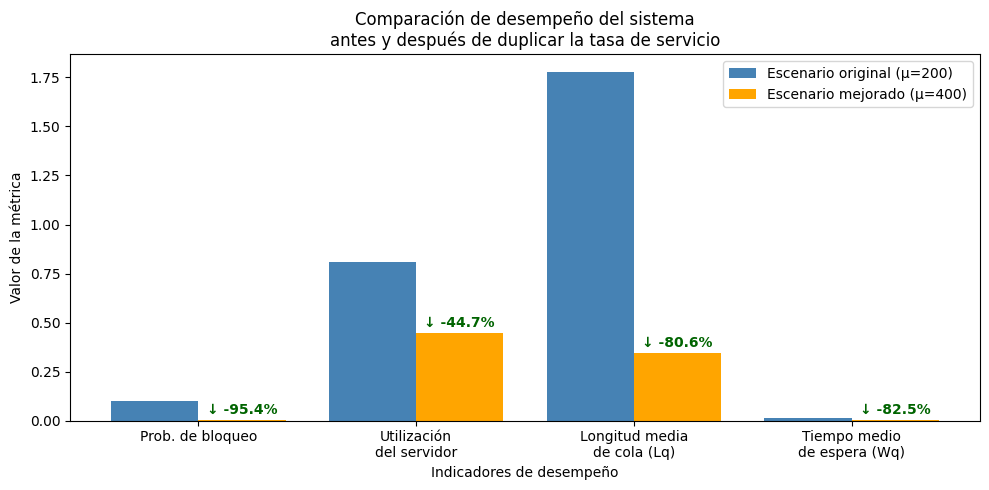

In [45]:
x = np.arange(4)

fig, ax = plt.subplots(figsize=(10,5))

bars1 = ax.bar(
    x-0.2,
    compare_mu['μ=200'],
    0.4,
    label='Escenario original (μ=200)',
    color='steelblue'
)

bars2 = ax.bar(
    x+0.2,
    compare_mu['μ=400'],
    0.4,
    label='Escenario mejorado (μ=400)',
    color='orange'
)

# Nombres más descriptivos
labels = [
    'Prob. de bloqueo',
    'Utilización\ndel servidor',
    'Longitud media\nde cola (Lq)',
    'Tiempo medio\nde espera (Wq)'
]

ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_ylabel('Valor de la métrica')
ax.set_xlabel('Indicadores de desempeño')
ax.set_title(
    'Comparación de desempeño del sistema\n'
    'antes y después de duplicar la tasa de servicio'
)

# Mostrar porcentaje sobre las barras naranjas
for i, bar in enumerate(bars2):

    altura = bar.get_height()
   
    cambio = compare_mu['Cambio (%)'].iloc[i]

    ax.text(
        bar.get_x() + bar.get_width()/2,
        altura + 0.03,
        f'↓ {cambio:.1f}%',
        ha='center',
        fontsize=10,
        fontweight='bold',
        color='darkgreen'
    )

ax.legend()
plt.tight_layout()
plt.show()

## Conclusiones
Los resultados obtenidos mostraron una alta coincidencia entre los valores calculados mediante las fórmulas analíticas del modelo M/M/1/K y los obtenidos a través de la simulación, lo que permite validar la precisión del modelo implementado. En el escenario inicial, con una tasa de llegada de 180 paquetes/s y una tasa de servicio de 200 paquetes/s, se observó que el sistema opera cerca de su capacidad, generando una mayor ocupación del servidor, incrementos en la longitud de la cola y una probabilidad apreciable de pérdida de paquetes.

Al duplicar la capacidad de servicio a 400 paquetes/s, los indicadores de desempeño mejoraron significativamente. La probabilidad de bloqueo disminuyó, las colas se redujeron y los paquetes experimentaron tiempos de espera considerablemente menores antes de ser atendidos. Asimismo, la utilización del servidor se redujo, permitiendo que el sistema operara con un mayor margen frente a variaciones en la carga de tráfico.

Estos resultados demuestran que la capacidad de servicio es un factor determinante en el desempeño de sistemas de comunicaciones con recursos limitados. En el contexto de las redes 5G, un adecuado dimensionamiento tanto del procesamiento como de la capacidad de almacenamiento contribuye a minimizar pérdidas de paquetes y retrasos, favoreciendo el cumplimiento de los requisitos de calidad de servicio (QoS) y mejorando la experiencia de los usuarios finales.

Realizado por Kassey Tavárez 10152171
